# Graph Neural Network (GNN) with CORA dataset: Node classification

In this sample code, we build two models to solve the same node classification problem:
- Deep Neural Network (DNN) model.
- Graph Neural Network (GNN) model.

The Cora dataset consists of 2708 scientific publications classified into one of seven classes. The citation network consists of 5429 links. Each publication in the dataset is described by a 0/1-valued word vector indicating the absence/presence of the corresponding word from the dictionary. The dictionary consists of 1433 unique words.

![Cora dataset](https://drive.google.com/uc?export=download&id=1Q13-PeSpIrqmnMLCtMCTKcSH_Dpk8eCN)

The Cora dataset consists of Machine Learning papers. These papers are classified into one of the following seven classes:
- Case_Based
- Genetic_Algorithms
- Neural_Networks
- Probabilistic_Methods
- Reinforcement_Learning
- Rule_Learning
- Theory

The papers were selected in a way such that in the final corpus every paper cites or is cited by atleast one other paper. There are 2708 papers in the whole corpus. After stemming and removing stopwords we were left with a vocabulary of size 1433 unique words. All words with document frequency less than 10 were removed.

The Cora dataset contains two files: .content and .cites

- The .content file contains descriptions of the papers in the following format:

		<paper_id> <word_attributes>+ <class_label>

The first entry in each line contains the unique string ID of the paper followed by binary values indicating whether each word in the vocabulary is present (indicated by 1) or absent (indicated by 0) in the paper. Finally, the last entry in the line contains the class label of the paper.

- The .cites file contains the citation graph of the corpus. Each line describes a link in the following format:

		<ID of cited paper> <ID of citing paper>

Each line contains two paper IDs. The first entry is the ID of the paper being cited and the second ID stands for the paper which contains the citation. The direction of the link is from right to left. If a line is represented by "paper1 paper2" then the link is "paper2->paper1".

More details can be found at https://graphsandnetworks.com/the-cora-dataset/.

# CORA dataset download and processing

In [88]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Dataset download

In [89]:
# Download CORA dataset. This dataset contains two files
# - cora.cites: contains the citation graph of the corpus: <ID of cited paper> <ID of citing paper>
# - cora.content: contains descriptions of the papers: <paper_id> <word_attributes>+ <class_label>
zip_file = keras.utils.get_file(
    fname="cora.tgz",
    origin="https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz",
    extract=True,
)
data_dir = os.path.join(os.path.dirname(zip_file), "cora")

In [90]:
# Read cora.cites. This file contains the citation graph.
citations = pd.read_csv(os.path.join(data_dir, "cora.cites"), sep="\t", header=None, names=["target", "source"])
print("Citations shape:", citations.shape)

# Print some citation samples
print("Citations shape:", citations.shape)
citations.sample(n=10)

Citations shape: (5429, 2)
Citations shape: (5429, 2)


,target,source
2215,19621,49482
3633,74975,38846
1878,12576,1107674
2068,16437,16474
1637,9513,102879
962,4330,1104449
1943,13658,198443
5123,621555,1130243
3142,45189,272720
2649,28504,1139928


In [91]:
# Read cora.content. This file contains descriptions of the papers.
column_names = ["paper_id"] + [f"word_{idx}" for idx in range(1433)] + ["subject"]
papers = pd.read_csv(os.path.join(data_dir, "cora.content"), sep="\t", header=None, names=column_names)

# Print some citation samples
print("Papers shape:", papers.shape)
papers.sample(n=10)

Papers shape: (2708, 1435)


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,subject
1358,157761,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Theory
270,134307,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods
587,1132418,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Neural_Networks
1368,112787,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based
2472,293271,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
137,126920,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods
69,1111614,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Case_Based
2342,3232,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Theory
675,63931,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Rule_Learning
2303,95642,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based


### Generate new mapping for paper index and subject index

In [92]:
# Get list of unique paper subjects / classes. These are the labels for Node (Paper) Classification.
class_values = sorted(papers["subject"].unique())

# Generate corresponding list of unique class indices
class_idx = {name: idx for idx, name in enumerate(class_values)}

# Generate list of unique class indices
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

In [93]:
### Map the original papers and citations information (paper_idx and class_idx) to the new information

# Map original paper index to the new paper index
papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])

# Map original paper subject (string) to the new paper subject (integer)
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

# Map original source/target paper index to the new source/target paper index
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])

In [94]:
# Print some citation samples with new index mapping
print("Citations shape:", citations.shape)
citations.sample(n=10)

Citations shape: (5429, 2)


,target,source
2322,348,1357
1019,87,2238
707,58,282
3871,852,1061
2545,406,226
720,60,39
1204,118,667
5001,1559,1865
1314,122,117
179,2,2212


In [95]:
# Print some citation samples with new index mapping
print("Papers shape:", papers.shape)
papers.sample(n=10)

Papers shape: (2708, 1435)


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,subject
2285,1716,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
411,294,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2324,1821,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
473,116,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1230,1581,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
611,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2084,633,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1574,322,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1966,1008,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2533,1849,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


### Split training and test set for node classification

In [96]:
# Set tup training, validation and test ratio. These ratios must sum up to one.
train_data, val_data, test_data = [], [], []
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Set random seed to get the same training set and test set in different running times.
np.random.seed(0)

# Select training_ratio from each group of paper subject to form the trainign set
for _, group_data in papers.groupby("subject"):
    #Get a random list of probabilities from a subject group
    random_probs = np.random.rand(len(group_data.index))

    # Get a random list of paper indices from a subject group
    random_selection_train = random_probs <= train_ratio
    random_selection_val = (train_ratio < random_probs) & (random_probs <= train_ratio + val_ratio)
    random_selection_test = 1 - test_ratio < random_probs

    # Add group DataFrames containing paper indices to training, validation and test set
    train_data.append(group_data[random_selection_train])
    val_data.append(group_data[random_selection_val])
    test_data.append(group_data[random_selection_test])

# Concat list of DataFrames to a big DataFrame for training and test dataset
train_data = pd.concat(train_data)
val_data = pd.concat(val_data)
test_data = pd.concat(test_data)

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_data.shape)

Training set: (1863, 1435)
Validation set: (405, 1435)
Test set: (440, 1435)


# Deep Neural Network (DNN) for node classification

### Process data features (word attributes) and labels (subjects) of papers

In [97]:
# List of features (word attributes) of a paper (node)
feature_names = set(papers.columns) - {"paper_id", "subject"}

# Create tensors of data samples
x_train = train_data[list(feature_names)].to_numpy()
x_val = val_data[list(feature_names)].to_numpy()
x_test = test_data[list(feature_names)].to_numpy()

# Create tensors of data labels
y_train = train_data["subject"]
y_val = val_data["subject"]
y_test = test_data["subject"]

# Number of features (word attributes) of a paper (node)
num_features = len(feature_names)

# Number of labels (subjects) of a paper
num_classes = len(class_idx)

### Set up DNN network hyper-parameters

In [98]:
# Feed Forward Network setup: number of FC layers and number of nodes in each FC layer
hidden_units = [32, 32]

# Feed Forward Network setup: dropout rate at DropOut layer
dropout_rate = 0.5

### Build DNN network

In [99]:
# Create a Feed Forward Network (FFN) as a Sequential model
def create_ffn(hidden_units_ffn, dropout_rate_ffn):
    fnn_layers = []

    for units in hidden_units_ffn:
        fnn_layers.append(layers.Dense(units, activation=tf.nn.gelu))
        fnn_layers.append(layers.Dropout(dropout_rate_ffn))
        fnn_layers.append(layers.BatchNormalization())

    # A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor
    return keras.Sequential(fnn_layers)

# Create a Deep Neural Network (DNN) for node classification
def create_dnn_model(hidden_units_ffn, dropout_rate_ffn, model_name):
    # Input of DNN is paper feature. Originally each paper has 1433 (num_features) word attributes as features.
    inputs = layers.Input(shape=(num_features,))

    # Embed the original features dimension to hidden_units space by using the Feed Forward Network (FFN).
    x = create_ffn(hidden_units_ffn, dropout_rate_ffn)(inputs)

    # Then perform feature extraction by using some skip connection blocks
    for block_idx in range(4):
        # Create an FFN block
        x1 = create_ffn(hidden_units_ffn, dropout_rate_ffn)(x)
        # Add skip connection
        x = x + x1

    # Add output layer
    outputs = layers.Dense(num_classes, activation = tf.nn.softmax)(x)

    # Create the model.
    return keras.Model(inputs=inputs, outputs=outputs, name=model_name)

dnn_model = create_dnn_model(hidden_units, dropout_rate, "DNN")
dnn_model.summary()

Model: "DNN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 1433)]       0           []                               
                                                                                                  
 sequential_33 (Sequential)     (None, 32)           47200       ['input_4[0][0]']                
                                                                                                  
 sequential_34 (Sequential)     (None, 32)           2368        ['sequential_33[0][0]']          
                                                                                                  
 tf.__operators__.add_12 (TFOpL  (None, 32)          0           ['sequential_33[0][0]',          
 ambda)                                                           'sequential_34[0][0]']        

### Train the DNN

In [100]:
# Compile the DNN model
dnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.01),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

# Train and validate the DNN model
history_dnn = dnn_model.fit(
    x = x_train,
    y = y_train,
    epochs = 100,
    batch_size = 1024,
    validation_data = (x_val, y_val)
)

Epoch 1/100
2/2 [==============================] - 10s 423ms/step - loss: 3.7082 - acc: 0.1503 - val_loss: 1.8578 - val_acc: 0.3160
Epoch 2/100
2/2 [==============================] - 0s 60ms/step - loss: 2.9271 - acc: 0.2067 - val_loss: 1.8312 - val_acc: 0.3160
Epoch 3/100
2/2 [==============================] - 0s 53ms/step - loss: 2.5770 - acc: 0.2335 - val_loss: 1.8161 - val_acc: 0.3160
Epoch 4/100
2/2 [==============================] - 0s 51ms/step - loss: 2.3601 - acc: 0.2797 - val_loss: 1.7977 - val_acc: 0.3160
Epoch 5/100
2/2 [==============================] - 0s 52ms/step - loss: 2.1431 - acc: 0.3247 - val_loss: 1.7792 - val_acc: 0.3160
Epoch 6/100
2/2 [==============================] - 0s 56ms/step - loss: 1.9471 - acc: 0.3435 - val_loss: 1.7592 - val_acc: 0.3160
Epoch 7/100
2/2 [==============================] - 0s 53ms/step - loss: 1.9224 - acc: 0.3360 - val_loss: 1.7389 - val_acc: 0.3160
Epoch 8/100
2/2 [==============================] - 0s 71ms/step - loss: 1.8665 - acc: 0.

### Evaluate DNN model performance on test set

In [101]:
dnn_model_eval = dnn_model.evaluate(x_test, y_test)
print("List of metrics" + str(dnn_model.metrics_names)) # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().
print("Test loss: " + str(dnn_model_eval[0])) # Test loss
print("Test accuracy: " + str(dnn_model_eval[1])) # Test accuracy

14/14 [==============================] - 0s 4ms/step - loss: 1.3610 - acc: 0.7386
List of metrics['loss', 'acc']
Test loss: 1.3609941005706787
Test accuracy: 0.7386363744735718


### Plot model training performance over epochs

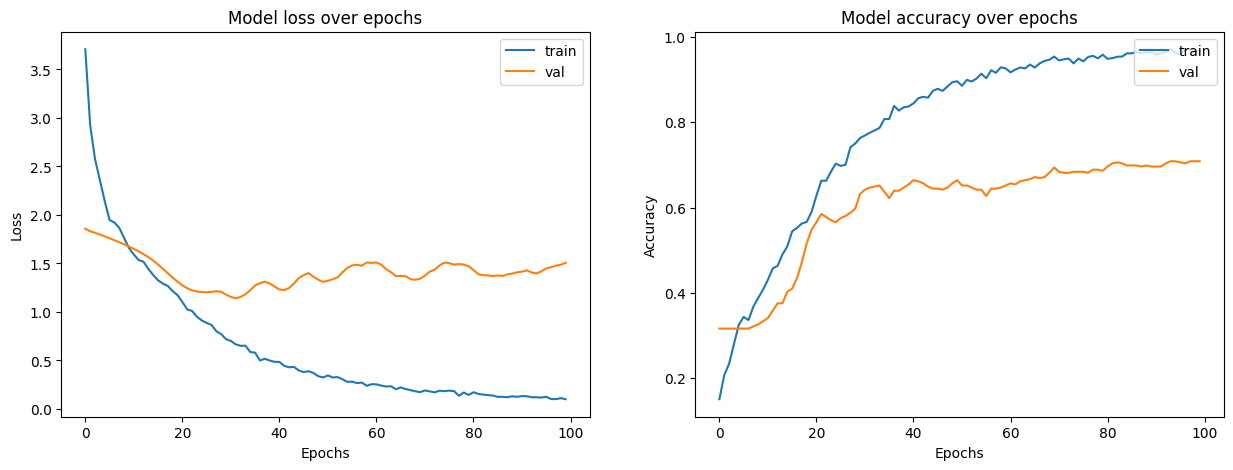

In [102]:
# Plot model performance during training
def plot_learning_curves(history):
    # Initialize the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot model loss during training
    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "val"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.set_title("Model loss over epochs")

    # Plot model accuracy during training
    ax2.plot(history.history["acc"])
    ax2.plot(history.history["val_acc"])
    ax2.legend(["train", "val"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Model accuracy over epochs")
    plt.show()

plot_learning_curves(history_dnn)

### Model testing on new nodes with DNN

In [103]:
# Generate new nodes. Each has a feature vector.
def generate_new_nodes(num_nodes):
    # Calculate probability of each feature (word attribute) in the feature vector.
    word_distribution = x_train.mean(axis=0)

    # Initialize new nodes vector
    new_nodes = []
    for _ in range(num_nodes):
        # Generate a random  for each feature
        rnd = np.random.uniform(size=len(word_distribution))

        # If the random value is less than the probability of the feature, the node has that feature / word attribute.
        # This makes sure that the frequency of the new nodes feature follows the same word attribute distribution of the original data.
        new_node = (rnd <= word_distribution).astype(int)

        # Append the new node feature vector of shape (1, 1433) to the new nodes vector
        new_nodes.append(new_node)

    # The new nodes array is of the shape (num_nodes, 1433)
    return np.array(new_nodes)

In [104]:
# Create new test nodes
test_nodes = generate_new_nodes(num_nodes = 3)

# Run the model with the new node to predict its subject
test_nodes_pred = dnn_model.predict(test_nodes)

# Output the subject class probability
for test_node_idx, probs in enumerate(test_nodes_pred):
    print("Test node: " + str(test_node_idx))
    print("- Word attribute features: " + str(np.nonzero(test_nodes[test_node_idx])))
    print("- Subjects: ")
    for class_idx, prob in enumerate(probs):
        print("   --- " + str(class_values[class_idx]) + ": " + str(prob))

1/1 [==============================] - 0s 305ms/step
Test node: 0
- Word attribute features: (array([ 168,  207,  300,  414,  497,  518,  543,  559,  572,  583,  610,
        642,  653,  706,  741,  748,  880,  966, 1034, 1148, 1216, 1346,
       1395]),)
- Subjects: 
   --- Case_Based: 0.006672599
   --- Genetic_Algorithms: 0.0014041772
   --- Neural_Networks: 0.04011295
   --- Probabilistic_Methods: 0.087546855
   --- Reinforcement_Learning: 0.0056428825
   --- Rule_Learning: 0.0031709357
   --- Theory: 0.8554496
Test node: 1
- Word attribute features: (array([ 169,  267,  419,  455,  518,  639,  675,  681,  797,  816,  952,
        977,  995, 1096, 1109, 1207, 1211, 1242, 1358, 1369]),)
- Subjects: 
   --- Case_Based: 5.244603e-05
   --- Genetic_Algorithms: 9.784641e-05
   --- Neural_Networks: 0.0005811849
   --- Probabilistic_Methods: 0.9990108
   --- Reinforcement_Learning: 5.8077735e-06
   --- Rule_Learning: 1.4571565e-06
   --- Theory: 0.00025049632
Test node: 2
- Word attribute

# Graph Neural Network (GNN) for node classification

### Create graph information

In [105]:
# Graph information contains:
# - Node information.
# - Edge information.

# Node information: is an array of node features of shape [num_nodes, num_features].
node_features = tf.cast(papers.sort_values("paper_id")[list(feature_names)].to_numpy(), dtype=tf.dtypes.float32)

# Edge information: is an array of edges (sparse adjacency matrix) of shape [2, num_edges].
edges = citations[["source", "target"]].to_numpy().T

# Create graph info tuple with node information and edge information
graph_info = (node_features, edges)

print("Node features shape:", node_features.shape)
print("Edges shape:", edges.shape)

Node features shape: (2708, 1433)
Edges shape: (2, 5429)


### Define Graph Neural Network layer

In [106]:
# Define a custom layer by extending the base class tensorflow.keras.layers.Layer
# Reference: https://keras.io/api/layers/base_layer/
class GNNLayer(layers.Layer):
    # Define a graph convolutional layer consisting of two operations:
    # - aggregate: sum of embeddings of neighbor nodes of a node.
    # - update: the node's embedding is updated by adding to aggregation result.

    # Defines custom layer attributes in __init__()
    def __init__(self, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Prepare the messages of neighbours, i.e., neighbour_messages
        self.ffn_prepare = create_ffn(hidden_units_ffn, dropout_rate_ffn)

        # Update the node embedding with the neighbour messages
        self.update_fn = create_ffn(hidden_units_ffn, dropout_rate_ffn)

    # Aggregate (sum) embeddings of neighbor nodes of a node
    # This aggregation can be sum, concat, mean, etc. In this sample code, we choose 'sum'.
    def aggregate(self, neighbour_messages, node_indices, node_embeddings):
        # Get number of nodes in the graph
        num_nodes = node_embeddings.shape[0]

        # Aggregate (sum) embeddings of neighbor nodes of all nodes; put results in a vector
        aggregated_message = tf.math.unsorted_segment_sum(neighbour_messages, node_indices, num_segments=num_nodes)

        # Return embedding result after aggregation
        return aggregated_message

    # Aggregation result from neighbors is added to the node's embedding to update the node
    def update(self, node_embeddings, aggregated_messages):
        # Add neighbors' embeddings to current node's embeddings, followed by a processing function (i.e., a feed forward network).
        node_embeddings = self.update_fn(node_embeddings + aggregated_messages)

        # Normalizes node embeddings to unit vectors, i.e., np.sum(node_embeddings[k]**2) = 1.0
        node_embeddings = tf.nn.l2_normalize(node_embeddings, axis=1)

        return node_embeddings

    # Function call() performs the logic of applying the layer to the input
    # Reference: https://keras.io/guides/making_new_layers_and_models_via_subclassing/
    def call(self, input_graph_info):
        # Process the input to produce the node_embeddings.
        # input (i.e., graph_info): a tuple of two elements: node_embeddings and edges
        # Returns: node_embeddings of shape [num_nodes, embedding_dim].

        # Extract node embeddings and edges from inputs, i.e., graph_info
        node_embeddings, edges = input_graph_info

        # Get source node indices and target neighbour indices from edges.
        source_node_indices, target_neighbour_indices = edges[0], edges[1]

        # Gather node embeddings of all target neighbours by their indices
        # neighbour_embeddings shape is [num_edges, embedding_dim]
        neighbour_embeddings = tf.gather(node_embeddings, target_neighbour_indices)

        # Prepare target neighbour embeddings by getting them through FFN (for complexity) to produce aggregation message
        neighbour_messages = self.ffn_prepare(neighbour_embeddings)

        # Aggregate the neighbour messages according to the current nodes, i.e., source_node_indices
        aggregated_messages = self.aggregate(neighbour_messages, source_node_indices, node_embeddings)

        # Update the current nodes with the aggregated messages.
        return self.update(node_embeddings, aggregated_messages)

### Define Graph Neural Network model

In [107]:
# Define a custom model by extending the base class tensorflow.keras.Model
# Reference: https://keras.io/api/models/model/
class GNNModel(tf.keras.Model):
    # Implement model architecture in __init()__ function
    def __init__(self, node_features, edges, num_classes, hidden_units_ffn, dropout_rate_ffn):
        # Inherit parent class initialization
        super().__init__()

        # Unpack graph_info into node_features and edges
        self.node_features = node_features
        self.edges = edges
        self.num_classes = num_classes
        self.hidden_units_ffn = hidden_units_ffn
        self.dropout_rate_ffn = dropout_rate_ffn

        # Create a process layer.
        self.preprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the first GraphConv layer.
        self.conv1 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create the second GraphConv layer.
        self.conv2 = GNNLayer(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a postprocess layer.
        self.postprocess = create_ffn(self.hidden_units_ffn, self.dropout_rate_ffn)

        # Create a classification layer.
        self.classify = layers.Dense(units = self.num_classes, activation = tf.nn.softmax)

    # Implement the model's forward pass in call() function
    # input_node_indices is the list of nodes in x_train or x_test split
    def call(self, input_node_indices):
        # Preprocess the node_features to produce node representations.
        x0 = self.preprocess(self.node_features)

        # Apply the first graph conv layer.
        x1 = self.conv1((x0, self.edges))

        # Skip connection.
        x2 = x1 + x0

        # Apply the second graph conv layer.
        x3 = self.conv2((x2, self.edges))

        # Skip connection.
        x4 = x3 + x2

        # Postprocess node embedding
        x5 = self.postprocess(x4)

        # Fetch node embeddings for the input_node_indices.
        # Reference: https://www.tensorflow.org/api_docs/python/tf/gather
        node_embeddings = tf.gather(x5, input_node_indices)

        # Compute classification output of node embeddings of input_node_indices
        # input_node_indices is x_train when training or x_test when testing
        return self.classify(node_embeddings)

### Build GNN

In [108]:
gnn_model = GNNModel(
    node_features = graph_info[0], # contains node features
    edges = graph_info[1], # contains edges
    num_classes = num_classes,
    hidden_units_ffn = hidden_units,
    dropout_rate_ffn = dropout_rate
)

# Instantiate and build the model on an arbitrary data sample: input_node_indices = [1], i.e. consisting of node index = 1
gnn_model([1])

# Print model architecture
gnn_model.summary()

Model: "gnn_model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_38 (Sequential)  (2708, 32)                47200     
                                                                 
 gnn_layer_6 (GNNLayer)      multiple                  4736      
                                                                 
 gnn_layer_7 (GNNLayer)      multiple                  4736      
                                                                 
 sequential_43 (Sequential)  (2708, 32)                2368      
                                                                 
 dense_95 (Dense)            multiple                  231       
                                                                 
Total params: 59,271
Trainable params: 58,503
Non-trainable params: 768
_________________________________________________________________


### Prepare training, validation and test set for GNN

In [109]:
# Prepare input_node_indices of x_train, x_val and x_test.
# These variables contain list of node indices belonging to training, validation and test set.
x_train_gnn = train_data.paper_id.to_numpy()
x_val_gnn = val_data.paper_id.to_numpy()
x_test_gnn = test_data.paper_id.to_numpy()

### Train the GNN

In [110]:
# Compile the DNN model
gnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.01),
    loss = keras.losses.SparseCategoricalCrossentropy(),
    metrics = [keras.metrics.SparseCategoricalAccuracy(name="acc")],
)

# Train and validate the DNN model
history_gnn = gnn_model.fit(
    x = x_train_gnn,
    y = y_train,
    epochs = 100,
    batch_size = 1024,
    validation_data = (x_val_gnn, y_val)
)

Epoch 1/100
2/2 [==============================] - 12s 532ms/step - loss: 2.4774 - acc: 0.1546 - val_loss: 1.8986 - val_acc: 0.3160
Epoch 2/100
2/2 [==============================] - 0s 43ms/step - loss: 2.1964 - acc: 0.2110 - val_loss: 1.8796 - val_acc: 0.3160
Epoch 3/100
2/2 [==============================] - 0s 41ms/step - loss: 2.1258 - acc: 0.2346 - val_loss: 1.8617 - val_acc: 0.3160
Epoch 4/100
2/2 [==============================] - 0s 42ms/step - loss: 2.0013 - acc: 0.2834 - val_loss: 1.8458 - val_acc: 0.3160
Epoch 5/100
2/2 [==============================] - 0s 62ms/step - loss: 1.9431 - acc: 0.2797 - val_loss: 1.8299 - val_acc: 0.3160
Epoch 6/100
2/2 [==============================] - 0s 43ms/step - loss: 1.8869 - acc: 0.3027 - val_loss: 1.8149 - val_acc: 0.3160
Epoch 7/100
2/2 [==============================] - 0s 43ms/step - loss: 1.8200 - acc: 0.3140 - val_loss: 1.7973 - val_acc: 0.3160
Epoch 8/100
2/2 [==============================] - 0s 56ms/step - loss: 1.7688 - acc: 0.

### Evaluate GNN model performance on test set

In [111]:
gnn_model_eval = gnn_model.evaluate(x_test_gnn, y_test)
print("List of metrics" + str(gnn_model.metrics_names))  # List of possible metrics of the model evaluation, this is the metrics specified in the model.compile().
print("Test loss: " + str(gnn_model_eval[0]))  # Test loss
print("Test accuracy: " + str(gnn_model_eval[1]))  # Test accuracy

14/14 [==============================] - 0s 5ms/step - loss: 0.6831 - acc: 0.8295
List of metrics['loss', 'acc']
Test loss: 0.6830608248710632
Test accuracy: 0.8295454382896423


### Plot GNN performance and DNN performance for comparison

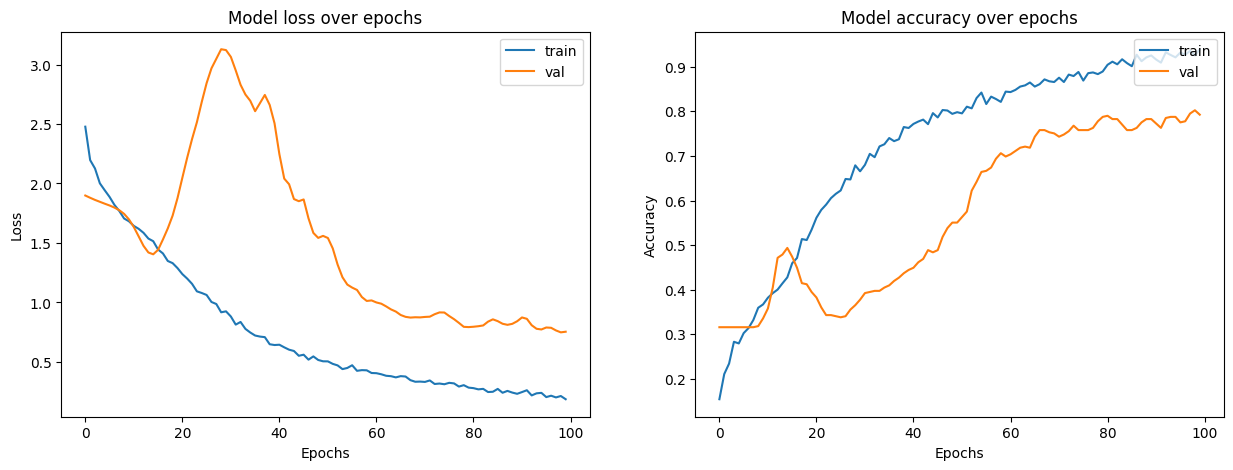

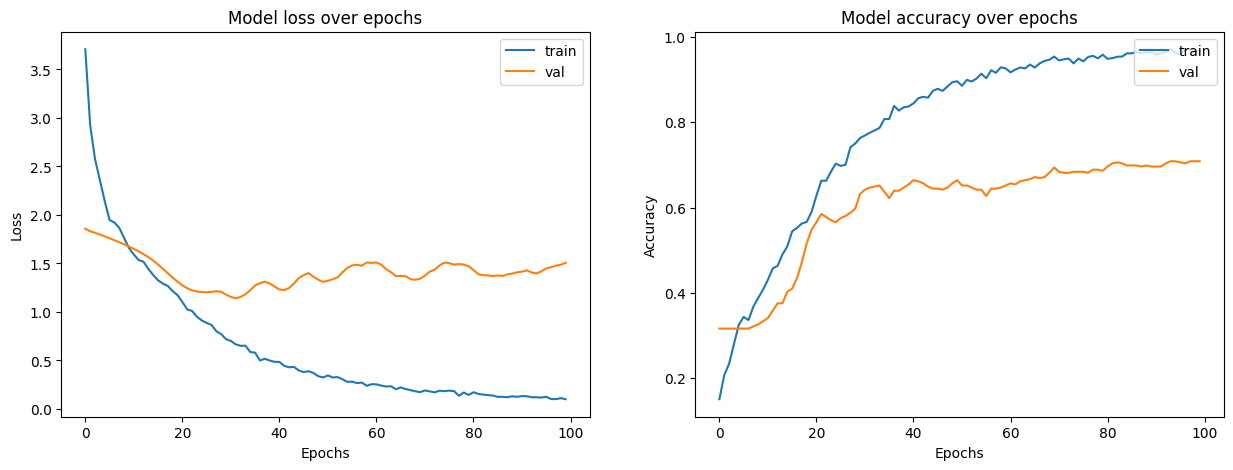

In [112]:
plot_learning_curves(history_gnn)
plot_learning_curves(history_dnn)

### Model testing on new nodes with GNN

Note: the GNN model must be re-compiled every time teh model is tested on new nodes.

In [113]:
### Create test nodes and append feature vectors of the new test nodes to the feature vectors of the original nodes
# Create new test nodes
test_nodes = generate_new_nodes(num_nodes = 3)

# Append the new test nodes to the node_features
new_node_features = np.concatenate([node_features, test_nodes])

In [114]:
### Create new edges from the new test nodes to original nodes
# Get number of original nodes, i.e., 2708 nodes
num_nodes = node_features.shape[0]

# Get indices for the new test nodes, i.e., 2708 + i
test_node_indices = [i + num_nodes for i in range(len(test_nodes))]

# Set outdegree (test node --> other nodes) and indegree (other nodes --> test node) for each of the new test nodes
test_node_outdegree = 20
test_node_indegree = 2

# Create a variable to store new citations, i.e., new edges
new_citations = []

# Generate random new citations, i.e., new edges, for each of the new test nodes
for test_node_index in test_node_indices:
    # Generate edges going out from the test node, i.e., outdegree
    target_nodes = np.random.randint(num_nodes, size = test_node_outdegree)
    for target_node in target_nodes:
        new_citations.append([target_node, test_node_index])

    # Generate edges coming to the test node, i.e., indegree
    source_nodes = np.random.randint(num_nodes, size = test_node_indegree)
    for source_node in source_nodes:
        new_citations.append([test_node_index, source_node])

# Add new edges to the set original edges
new_citations = np.array(new_citations).T
new_edges = np.concatenate([edges, new_citations], axis=1)

In [115]:
# Print original shape, i.e., number of nodes and edges, of the GNN model
gnn_model.node_features = node_features
gnn_model.edges = edges

print("Original node_features shape:", gnn_model.node_features.shape)
print("Original edges shape:", gnn_model.edges.shape)

# Print new shape, i.e., number of nodes and edges, of the GNN model after adding new nodes and edges
gnn_model.node_features = new_node_features
gnn_model.edges = new_edges

print("New node_features shape:", gnn_model.node_features.shape)
print("New edges shape:", gnn_model.edges.shape)

Original node_features shape: (2708, 1433)
Original edges shape: (2, 5429)
New node_features shape: (2711, 1433)
New edges shape: (2, 5495)


In [116]:
# Run prediction on the new test nodes to predict subjects
test_nodes_pred = gnn_model.predict(test_node_indices)

# Output the subject class probability
for test_node_idx, probs in enumerate(test_nodes_pred):
    print("Test node: " + str(test_node_idx))
    print("- Word attribute features: " + str(np.nonzero(test_nodes[test_node_idx])))
    print("- Subjects: ")
    for class_idx, prob in enumerate(probs):
        print("   --- " + str(class_values[class_idx]) + ": " + str(prob))

1/1 [==============================] - 1s 1s/step
Test node: 0
- Word attribute features: (array([   6,  369,  414,  516,  518,  583,  601,  603,  624,  641,  727,
        730,  735,  740,  756,  764,  801,  862,  875,  900, 1117, 1143,
       1189, 1203, 1328, 1358, 1368]),)
- Subjects: 
   --- Case_Based: 0.0003109935
   --- Genetic_Algorithms: 0.0032828837
   --- Neural_Networks: 0.98404425
   --- Probabilistic_Methods: 0.007320718
   --- Reinforcement_Learning: 0.0025278998
   --- Rule_Learning: 0.00018913901
   --- Theory: 0.002324252
Test node: 1
- Word attribute features: (array([  92,  131,  183,  197,  660,  666,  693,  758,  768,  776,  801,
        891, 1134, 1234, 1239, 1370, 1395, 1416]),)
- Subjects: 
   --- Case_Based: 0.001393125
   --- Genetic_Algorithms: 0.008044679
   --- Neural_Networks: 0.9103128
   --- Probabilistic_Methods: 0.044864953
   --- Reinforcement_Learning: 0.007988693
   --- Rule_Learning: 0.0016324791
   --- Theory: 0.025763359
Test node: 2
- Word attr